# 07 · Coating, layers & substrate — deconvolution (Physics + ML)

*A real CrN/Cr/Si stack with a milled logo — separate the layers from what's underneath.*

> ⏱ **Runtime:** ~15 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** CrN/Cr/Si multilayer (4D) + synthetic

### 🎯 What you'll learn
1. why a coating's measured hardness **depends on depth** (layers + substrate contribute),
2. how **clustering** a real milled map recovers the **pattern** (intact coating vs milled),
3. a **physics deconvolution** of a full **multilayer** (CrN/Cr/Si) that recovers each layer,
4. an **ML** model that *learns* the deconvolution from examples.

### 🧭 What you need to know first
- Clustering (notebook **02**) and curve fitting (**12**).
- The idea of a depth-resolved indentation measurement (notebook 00).

> 🔬 **The sample.** A physical-vapour-deposited stack: **CrN (200 nm) on Cr (200 nm) on a
> Si(100) wafer** (silicon modulus ≈ 165 GPa, Poisson's ratio 0.257). A **logo was milled** into
> it — the CrN is removed in the pattern, exposing the softer **Cr** underneath.
>
> **Key consequence.** These high-speed indents only reach **~64 nm** — far less than the 200 nm
> top layer. So each indent senses **only the top layer**: hard **CrN** where the coating is intact,
> soft **Cr** where it was milled. The hardness map therefore *is* a map of the milled logo. To see
> the deeper Cr→Si transitions you'd need to indent much deeper — which we explore with synthetic
> data. No proprietary data is used.

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> 🟢 **On Google Colab** this cell also clones the repo and installs a few extra packages — it takes about a minute the first time. On your own machine (after `pip install -r requirements.txt`) it's instant.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


In [2]:
from scipy.optimize import curve_fit
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
rng = np.random.default_rng(0)

## 1 · The real coating: hardness vs depth

Each indent carries a full **hardness-vs-depth** curve (continuous-stiffness measurement). Let's
load them and look at the depth trend.

> 🧠 **layer / substrate** — the coating stack has a top layer (CrN), an interlayer (Cr) and the substrate (Si). We want to tell them apart from the mechanical response.

> ✅ **When you run the next cell, you should see:** the data shape (~1000+ indents × 44 depth points, ≤64 nm) and hardness-vs-depth curves: most rise to the CrN plateau (~16 GPa); some stay low (the milled Cr).

indents: 1160  depth points: 44  (max depth 64 nm  «  200 nm CrN layer)


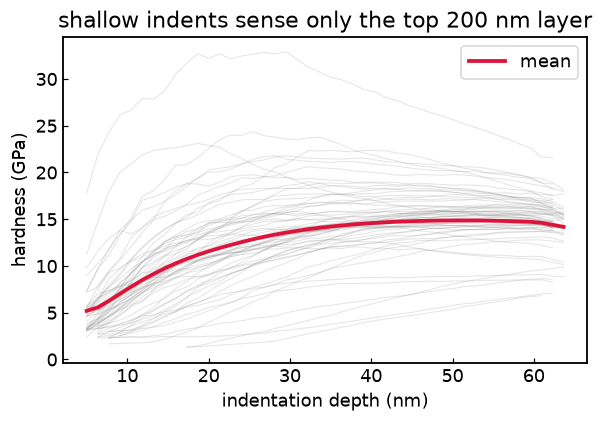

In [3]:
d4 = mm.load_4d("crn_cr_bilayer")          # dict: depth_nm, H, E (n_indents, n_depth), X, Y
depth = d4["depth_nm"]; H = d4["H"]; E = d4["E"]
print("indents:", H.shape[0], " depth points:", H.shape[1],
      f" (max depth {depth[-1]:.0f} nm  «  200 nm CrN layer)")

fig, ax = plt.subplots(figsize=(5.6, 4))
for i in rng.choice(H.shape[0], 60, replace=False):
    ax.plot(depth, H[i], color="grey", alpha=0.2, lw=0.7)
ax.plot(depth, np.nanmean(H, 0), "crimson", lw=2.5, label="mean")
ax.set_xlabel("indentation depth (nm)"); ax.set_ylabel("hardness (GPa)")
ax.legend(); ax.set_title("shallow indents sense only the top 200 nm layer"); fig.tight_layout()

*🖼 **Figure.** Curves climb out of a noisy first few nm (surface artefact) toward the CrN plateau (~16 GPa); a minority sit much lower — those indents are on the milled areas where soft Cr is exposed. Nothing reaches the Cr→Si depths (≥200 nm).*

## 2 · Recover the milled logo by clustering

Because each indent measures either **CrN** (hard) or **Cr** (soft), an *unsupervised* split of the
depth curves into two groups should map straight onto the **milled pattern** — no labels needed
(same idea as notebook 02).

> 🧠 **clustering here** — group the indents by the level of their hardness curve; the harder group is intact CrN, the softer one is where the coating was milled/thinned.

> ✅ **When you run the next cell, you should see:** three panels: a **continuous hardness map that shows the milled lattice**, the same map **segmented** by clustering, and the two groups' mean curves (harder intact CrN ≈ 17 GPa vs softer milled ≈ 13 GPa).

softer (milled / thinned) fraction: 59%
group mean hardness — intact CrN: 17.4 GPa   milled/thinned: 12.9 GPa


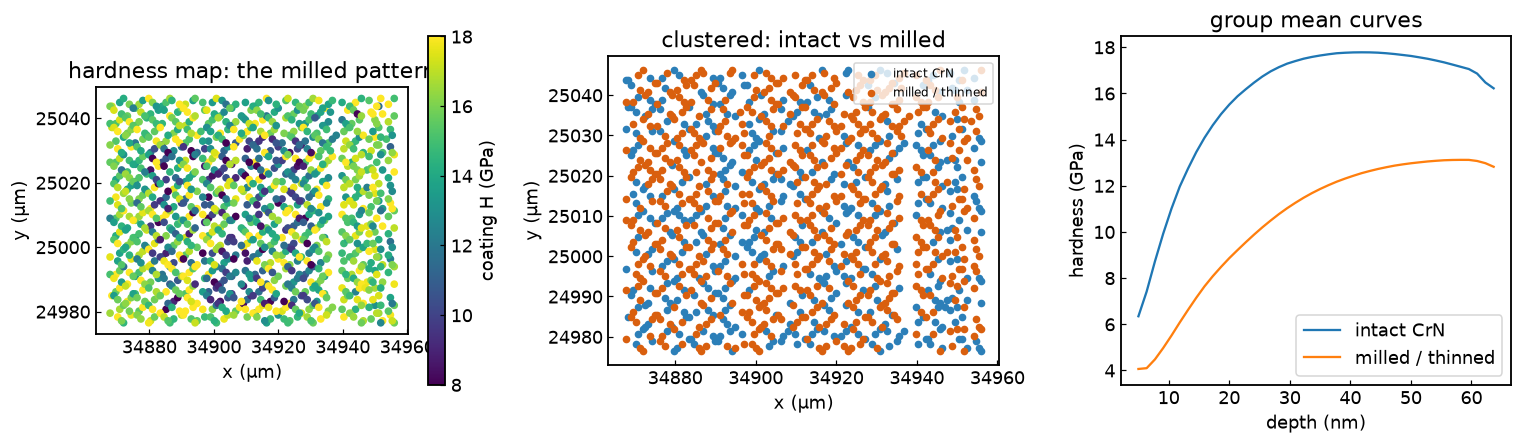

In [4]:
X, Y = d4["X"], d4["Y"]
band_s = (depth >= 15) & (depth <= 30)
band_d = (depth >= 40) & (depth <= 63)
Hdeep = np.nanmean(H[:, band_d], 1)         # coating hardness per indent (plateau band)

# feature per indent: shallow + deep hardness (imputed for the few missing points)
feats = SimpleImputer(strategy="median").fit_transform(
    np.column_stack([np.nanmean(H[:, band_s], 1), Hdeep]))
km = KMeans(2, n_init=10, random_state=0).fit(feats)
lab = km.labels_
soft = lab == int(np.argmin([feats[lab == c, 1].mean() for c in (0, 1)]))   # lower-hardness group
print(f"softer (milled / thinned) fraction: {100*soft.mean():.0f}%")
print(f"group mean hardness — intact CrN: {feats[~soft,1].mean():.1f} GPa   "
      f"milled/thinned: {feats[soft,1].mean():.1f} GPa")

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
s = ax[0].scatter(X, Y, c=Hdeep, s=16, cmap="viridis", vmin=8, vmax=18)
plt.colorbar(s, ax=ax[0], label="coating H (GPa)"); ax[0].set_title("hardness map: the milled pattern")
ax[1].scatter(X[~soft], Y[~soft], s=16, c="#2c7fb8", label="intact CrN")
ax[1].scatter(X[soft], Y[soft], s=16, c="#d95f0e", label="milled / thinned")
ax[1].legend(loc="upper right", fontsize=8); ax[1].set_title("clustered: intact vs milled")
ax[2].plot(depth, np.nanmean(H[~soft], 0), label="intact CrN")
ax[2].plot(depth, np.nanmean(H[soft], 0), label="milled / thinned")
ax[2].set_xlabel("depth (nm)"); ax[2].set_ylabel("hardness (GPa)"); ax[2].legend(); ax[2].set_title("group mean curves")
for a in ax[:2]: a.set_aspect("equal"); a.set_xlabel("x (µm)"); a.set_ylabel("y (µm)")
fig.tight_layout()

*🖼 **Figure.** Left: the raw coating-hardness map already traces the **milled lattice** — softer lines where the CrN was thinned/removed cut through the harder intact coating. Middle: clustering segments the two automatically. The milling is gradational (partly thinned CrN, not always bare Cr), so the softer group sits below the intact CrN rather than at pure-Cr hardness.*

## 3 · The full multilayer, taught on synthetic data

To *see* the Cr→Si transitions you must indent far deeper than this map goes. So — as we validated
the pop-in detector on a synthetic curve (notebook 11) — we build a **synthetic multilayer** with the
real stack (**CrN/Cr/Si**, interfaces at 200 and 400 nm) and known layer hardness, then fit it back.

> 🧠 **multilayer deconvolution** — fitting a model with one value per layer to the depth curve, so you recover each layer's property despite them blending together.

> ✅ **When you run the next cell, you should see:** printed **true vs recovered** hardness for all three layers (CrN, Cr, Si) — they should match within ~1 GPa — and a plot of the noisy synthetic curve with the fit.

CrN  H1: true 22.0 -> recovered 22.1 GPa
Cr   H2: true 5.0 -> recovered 5.0 GPa
Si   H3: true 12.0 -> recovered 12.0 GPa


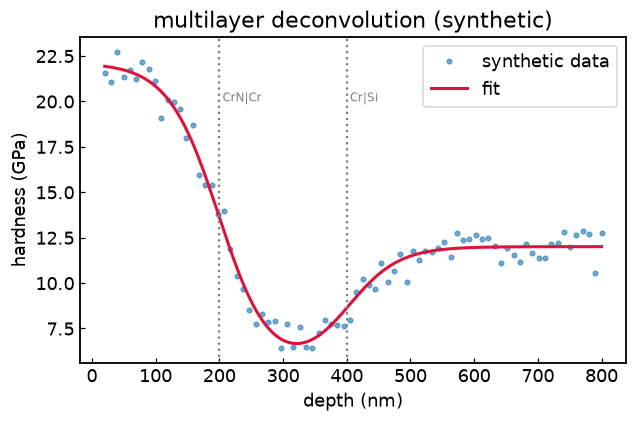

In [5]:
def multilayer(z, H1, H2, H3, w=40.0, t1=200.0, t2=400.0):
    # smooth transitions at the CrN/Cr interface (t1) and the Cr/Si interface (t2)
    S = lambda x: 1.0 / (1.0 + np.exp(-x / w))
    return H1 + (H2 - H1) * S(z - t1) + (H3 - H2) * S(z - t2)

H1_true, H2_true, H3_true = 22.0, 5.0, 12.0        # CrN, Cr, Si hardness (GPa)
z_syn = np.linspace(20, 800, 80)                    # indent deep enough to cross both interfaces
H_syn = multilayer(z_syn, H1_true, H2_true, H3_true) + rng.normal(0, 0.6, z_syn.size)

p0 = [H_syn[:5].mean(), H_syn[z_syn > 300][:5].mean(), H_syn[-5:].mean()]
(H1f, H2f, H3f), _ = curve_fit(multilayer, z_syn, H_syn, p0=p0, maxfev=10000)
print(f"CrN  H1: true {H1_true:.1f} -> recovered {H1f:.1f} GPa")
print(f"Cr   H2: true {H2_true:.1f} -> recovered {H2f:.1f} GPa")
print(f"Si   H3: true {H3_true:.1f} -> recovered {H3f:.1f} GPa")

fig, ax = plt.subplots(figsize=(5.8, 4))
ax.plot(z_syn, H_syn, "o", ms=3, alpha=.6, label="synthetic data")
zz = np.linspace(20, 800, 300); ax.plot(zz, multilayer(zz, H1f, H2f, H3f), "crimson", lw=2, label="fit")
for t, name in [(200, "CrN|Cr"), (400, "Cr|Si")]:
    ax.axvline(t, ls=":", c="grey"); ax.text(t + 5, 20, name, color="grey", fontsize=8)
ax.set_xlabel("depth (nm)"); ax.set_ylabel("hardness (GPa)"); ax.legend(); ax.set_title("multilayer deconvolution (synthetic)")
fig.tight_layout()

*🖼 **Figure.** With deep-enough indentation the model recovers all three layer hardnesses from one blended curve — the hard CrN, the soft Cr interlayer, and the Si substrate. This is the 'multiple layer effects' deconvolution, validated.*

## 4 · Let ML *learn* the deconvolution

Fitting a model per curve is fine for a few, slow for millions. Can a model learn to read the **coating**
(CrN) hardness straight from depth points that are **contaminated by the layers below**? We test it on
many synthetic stacks with *random* layer properties, where we know the truth.

> ✅ **When you run the next cell, you should see:** a parity plot (predicted vs true CrN hardness) with **R² ≈ 0.9** — the model learned to undo the layer blending.

R^2 = 0.977


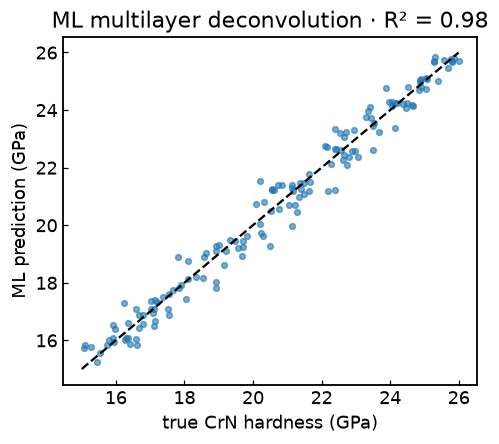

In [6]:
N = 500
H1r = rng.uniform(15, 26, N); H2r = rng.uniform(3, 8, N); H3r = rng.uniform(9, 14, N)
z_probe = np.array([50, 150, 250, 400, 600])        # depths spanning the whole stack
Xsyn = np.array([multilayer(z_probe, a, b, c) + rng.normal(0, 0.5, z_probe.size)
                 for a, b, c in zip(H1r, H2r, H3r)])

Xtr, Xte, ytr, yte = train_test_split(Xsyn, H1r, test_size=0.3, random_state=0)
reg = RandomForestRegressor(300, random_state=0, n_jobs=-1).fit(Xtr, ytr)
pred = reg.predict(Xte); r2 = r2_score(yte, pred)

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.scatter(yte, pred, s=14, alpha=.6); lim = [H1r.min(), H1r.max()]
ax.plot(lim, lim, "k--"); ax.set_xlabel("true CrN hardness (GPa)"); ax.set_ylabel("ML prediction (GPa)")
ax.set_title(f"ML multilayer deconvolution · R² = {r2:.2f}"); fig.tight_layout()
print("R^2 =", round(r2, 3))

*🖼 **Figure.** From depth readings that mix all three layers, the random forest recovers the top-coating hardness across hundreds of varied stacks — it *learned* the deconvolution.*

### ✅ Self-check
A quick sanity test that the numbers above came out sensible. If you edit the notebook and a result drifts badly, the cell below will stop with an `AssertionError` — a helpful early warning, not a bug.

In [7]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert 0.05 < soft.mean() < 0.8, "clustering should split into a harder and a softer group"
assert feats[~soft,1].mean() - feats[soft,1].mean() > 3, "intact-CrN group should be clearly harder than the milled group"
assert abs(H1f-H1_true)<2 and abs(H2f-H2_true)<2 and abs(H3f-H3_true)<2, "synthetic layers should be recovered"
assert r2 > 0.6, "ML should predict the coating hardness from the multilayer curve"
print("self-check passed ✓ — milled pattern + multilayer recovered")

self-check passed ✓ — milled pattern + multilayer recovered


## ✅ Recap
- Shallow HSNM senses only the **top layer**, so clustering the CrN/Cr map **recovers the milled logo** — unsupervised.
- A **multilayer model** (CrN/Cr/Si) fitted to a deep-enough curve recovers **every layer** — validated on synthetic data.
- An **ML** model learns the same deconvolution from examples — a fast surrogate for the per-curve fit.

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. In Part 2, cluster into **3** groups (`KMeans(3)`) — do you separate intact CrN, milled Cr, and edges/interfaces?
2. Repeat the multilayer fit in Part 3 for **modulus**: set the layer moduli to CrN≈350, Cr≈279, Si≈165 GPa.
3. Move the Cr/Si interface (`t2`) in Part 3 to 300 nm. Does the fit still recover the three hardnesses?

## 🩹 Common errors & fixes
- **`RuntimeError: Optimal parameters not found`** → improve `p0`, or widen `maxfev`; make sure the synthetic curve crosses both interfaces.
- **Clusters look swapped** → cluster ids are arbitrary; we label the lower-hardness cluster as 'milled'.
- **`FileNotFoundError` for the 4D csv** → run the set-up cell first so `mm.load_4d` finds `data/nanoindent_4d/`.

---
**Next:** the refreshed classics (**10–13**), or revisit **02** — the clustering that recovered the logo here is the same tool that found phases there.